This notebook downloads and performs the FIXED-SKY analysis on GW190521 data.

We assume a ringdown model with 330+220 modes. 

We also calculate the $\ln\mathcal{B}^{330+220}_{220}$

In [1]:
import os

# jax device and parallelization flags on m4 mac.
# modify as needed.
os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=12"

import sys
sys.path.append('../../src/')

import numpy as onp
import jax
import jax.numpy as jnp
import lal


from myutils_2233 import Ntime, ACFs, set_detectors, cov_resp
from myutils_2233 import ln_likelihood_full_jit


from scipy.linalg import toeplitz
import scipy.signal as sig

from other_utils import bandpass_ds, analysis_data, interp1d_jax, load_tables
from gwpy.timeseries import TimeSeries

jax.config.update("jax_enable_x64", True) 

/var/folders/ym/96hpxg7j71d8y7qhmy0qh0p80000gn/T/ipykernel_29510/1105002132.py:14: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from corner import corner
from chainconsumer import Chain, ChainConsumer, Truth, ChainConfig, PlotConfig

import numpyro
from numpyro.contrib.nested_sampling import NestedSampler
import numpyro.distributions as dist

import h5py


numpyro.enable_x64()

/Users/kallol/miniconda3/envs/skyloc_ringdown/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data download parameters

This uses data downloaded directly from gwpy.

Set the parameters to download the strain.

In [3]:
# Event data downloaded using gwpy.
# Starting at t_ref = t_peak + 6ms as reported in Capano et al

tgps = 1242442967.445 + 0.006 
seglen = 8 
fs = 16384 
fmin = 8 
event_id = "GW190521" 
plot_checks = 0 
T = 0.2 
srate = 4096 

ra = 3.5    #right ascension
dec = 0.73  #declination


factor = 10
seed       = 31567
t0         = 0.0
fmax       = 1500

qnm1_path  = "../../data/l2/n1l2m2.dat"
qnm2_path  = "../../data/l3/n1l3m3.dat"

Fetching strain data for H1 and L1

In [4]:
dH1 = TimeSeries.fetch_open_data('H1', tgps - seglen/2, tgps + seglen/2, sample_rate=fs)
dL1 = TimeSeries.fetch_open_data('L1', tgps - seglen/2, tgps + seglen/2, sample_rate=fs)

Calculate H1 and L1 starting times corresponding the reported sky locations (ra=3.5, dec=0.75). 

Calculate PSDs directly from the data.

In [5]:
n_analyze = Ntime(srate, T)

# Calculate H1 and L1 times

delays = {}
tgps_ = lal.LIGOTimeGPS(tgps)
gmst = lal.GreenwichMeanSiderealTime(tgps_)
dt_ifo = delays.get('H1',
                    lal.TimeDelayFromEarthCenter(lal.CachedDetectors[lal.LALDetectorIndexLHODIFF].location, ra, dec, tgps))
tH1 = tgps + dt_ifo

delays = {}
tgps_ = lal.LIGOTimeGPS(tgps)
gmst = lal.GreenwichMeanSiderealTime(tgps_)
dt_ifo = delays.get('L1',
                    lal.TimeDelayFromEarthCenter(lal.CachedDetectors[lal.LALDetectorIndexLLODIFF].location, ra, dec, tgps))
tL1 = tgps + dt_ifo

print('H1 start time : ', onp.float64(tH1))
print('L1 start time : ', onp.float64(tL1))


dH1_cond = bandpass_ds(dH1, t0=tH1, ds=int(fs/srate), trim=0.25, f_min=fmin)
dL1_cond = bandpass_ds(dL1, t0=tL1, ds=int(fs/srate), trim=0.25, f_min=fmin)

# Calculate PSDs


nperseg = int(seglen * (1/(dH1.times.value[1] - dH1.times.value[0])))
noverlap = nperseg // 2

psdH = sig.welch(
    dH1.value,
    fs=fs,
    window="hann",
    nperseg=4096*4,
    noverlap=4096*2,
    detrend=False,
    return_onesided=True,
    scaling="density",    
)

psdL = sig.welch(
    dL1.value,
    fs=fs,
    window="hann",
    nperseg=4096*4,
    noverlap=4096*2,
    detrend=False,
    return_onesided=True,
    scaling="density",   
)

H1 start time :  1242442967.4318974
L1 start time :  1242442967.4302728


Set priors for the PE

In [6]:
# Prior limits
limits = [
    [150.0, 500.0],
    [0., 0.99],
    [0., 4.0],
    [0., 6.283185307179586],
    [0., 4.0],
    [0., 6.283185307179586],
    [-1., 1.],
    [0., 3.141592653589793]]

low  = onp.asarray([pair[0] for pair in limits], dtype=onp.float64)
high = onp.asarray([pair[1] for pair in limits], dtype=onp.float64)

Interpolating PSDs over freq range, setting up cov (using Cholesky decomposition approach) for TD likelihood

In [7]:
psdH = interp1d_jax(jnp.asarray(psdH[0],dtype=jnp.float64), jnp.asarray(psdH[1],dtype=jnp.float64))
psdL = interp1d_jax(jnp.asarray(psdL[0],dtype=jnp.float64), jnp.asarray(psdL[1],dtype=jnp.float64))

omega_22_r, omega_22_i, omega_33_r, omega_33_i = load_tables(qnm1_path, qnm2_path)
tgps = lal.LIGOTimeGPS(tgps)
gmst = lal.GreenwichMeanSiderealTime(tgps)

L_H, L_L, resp_H, resp_L = cov_resp(srate=srate, T=T, psdH=psdH, psdL=psdL, factor=factor)
set_detectors(resp_H, resp_L)

In [8]:
# data strain starting from the respective detector times as calculated from tgps and sky location
# for the Fixed-sky analysis
dH1_analysis_data = analysis_data(dH1_cond[1], dH1_cond[0], tH1, n_analyze)
dL1_analysis_data = analysis_data(dL1_cond[1], dL1_cond[0], tL1, n_analyze)

h_H_t = dH1_analysis_data[1]
h_L_t = dL1_analysis_data[1]

Set up the numpyro model. Computes likelihood as a function of $\theta$

In [9]:
low  = jnp.asarray(low,  dtype=jnp.float64)  
high = jnp.asarray(high, dtype=jnp.float64)   

theta_fixed_sky = jnp.array([ra, onp.sin(dec)]) 


def make_loglik_fn(dataH, dataL, gmst, L_H, L_L,
                omega_22_r, omega_22_i, omega_33_r, omega_33_i,
                T, srate, t0):
    def _loglik(theta):
        return ln_likelihood_full_jit(
            dataH=dataH, dataL=dataL, params=theta,
            gmst=gmst, L_H=L_H, L_L=L_L,
            omega_22_r=omega_22_r, omega_22_i=omega_22_i,
            omega_33_r=omega_33_r, omega_33_i=omega_33_i,
            T=T, srate=srate, t0=t0
        )
    return _loglik

loglik_fn = make_loglik_fn(
    dataH=h_H_t, dataL=h_L_t,
    gmst=gmst, L_H=L_H, L_L=L_L,
    omega_22_r=omega_22_r, omega_22_i=omega_22_i,
    omega_33_r=omega_33_r, omega_33_i=omega_33_i,
    T=T, srate=srate, t0=t0
)

def model_fixed_sky():
    theta_free = numpyro.sample("theta", dist.Uniform(low, high))
    theta = jnp.concatenate([theta_free[:-1], theta_fixed_sky, jnp.array([theta_free[-1]])], axis=0)
    numpyro.factor("loglike", loglik_fn(theta))

In [10]:
rng_key = jax.random.PRNGKey(int(seed) ^ 0xABCDEF)
rng_run, rng_post = jax.random.split(rng_key)
ns_fixed_sky = NestedSampler(
    model_fixed_sky,
    constructor_kwargs=dict(
        num_live_points=10000,     
        max_samples=500_000,     
        verbose=False,
    ),
    termination_kwargs=dict(
        dlogZ=0.01,             
    ),
)
ns_fixed_sky.run(rng_run)
ns_fixed_sky.print_summary()
posterior_fixed_sky = ns_fixed_sky.get_samples(rng_post, num_samples=100_000)

INFO:jaxns:Number of Markov-chains set to: 10000


Running over 12 devices.
--------
Termination Conditions:
Small remaining evidence
--------
likelihood evals: 27240517
samples: 195156
phantom samples: 0
likelihood evals / sample: 139.6
phantom fraction (%): 0.0%
--------
logZ=-821.811 +- 0.046
max(logL)=-803.119
H=-14.43
ESS=26084
--------
theta[#]: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
theta[0]: 323.0 +- 33.0 | 281.0 / 324.0 / 363.0 | 349.0 | 349.0
theta[1]: 0.83 +- 0.11 | 0.7 / 0.85 / 0.93 | 0.91 | 0.91
theta[2]: 0.32 +- 0.2 | 0.15 / 0.26 / 0.54 | 0.23 | 0.23
theta[3]: 3.4 +- 1.7 | 1.4 / 3.0 / 5.6 | 2.2 | 2.2
theta[4]: 0.118 +- 0.079 | 0.04 / 0.102 / 0.208 | 0.223 | 0.223
theta[5]: 3.3 +- 1.8 | 0.6 / 3.3 / 5.7 | 5.8 | 5.8
theta[6]: 0.04 +- 0.4 | -0.49 / 0.06 / 0.56 | -0.04 | -0.04
theta[7]: 1.7 +- 0.89 | 0.5 / 1.77 / 2.83 | 2.7 | 2.7
--------


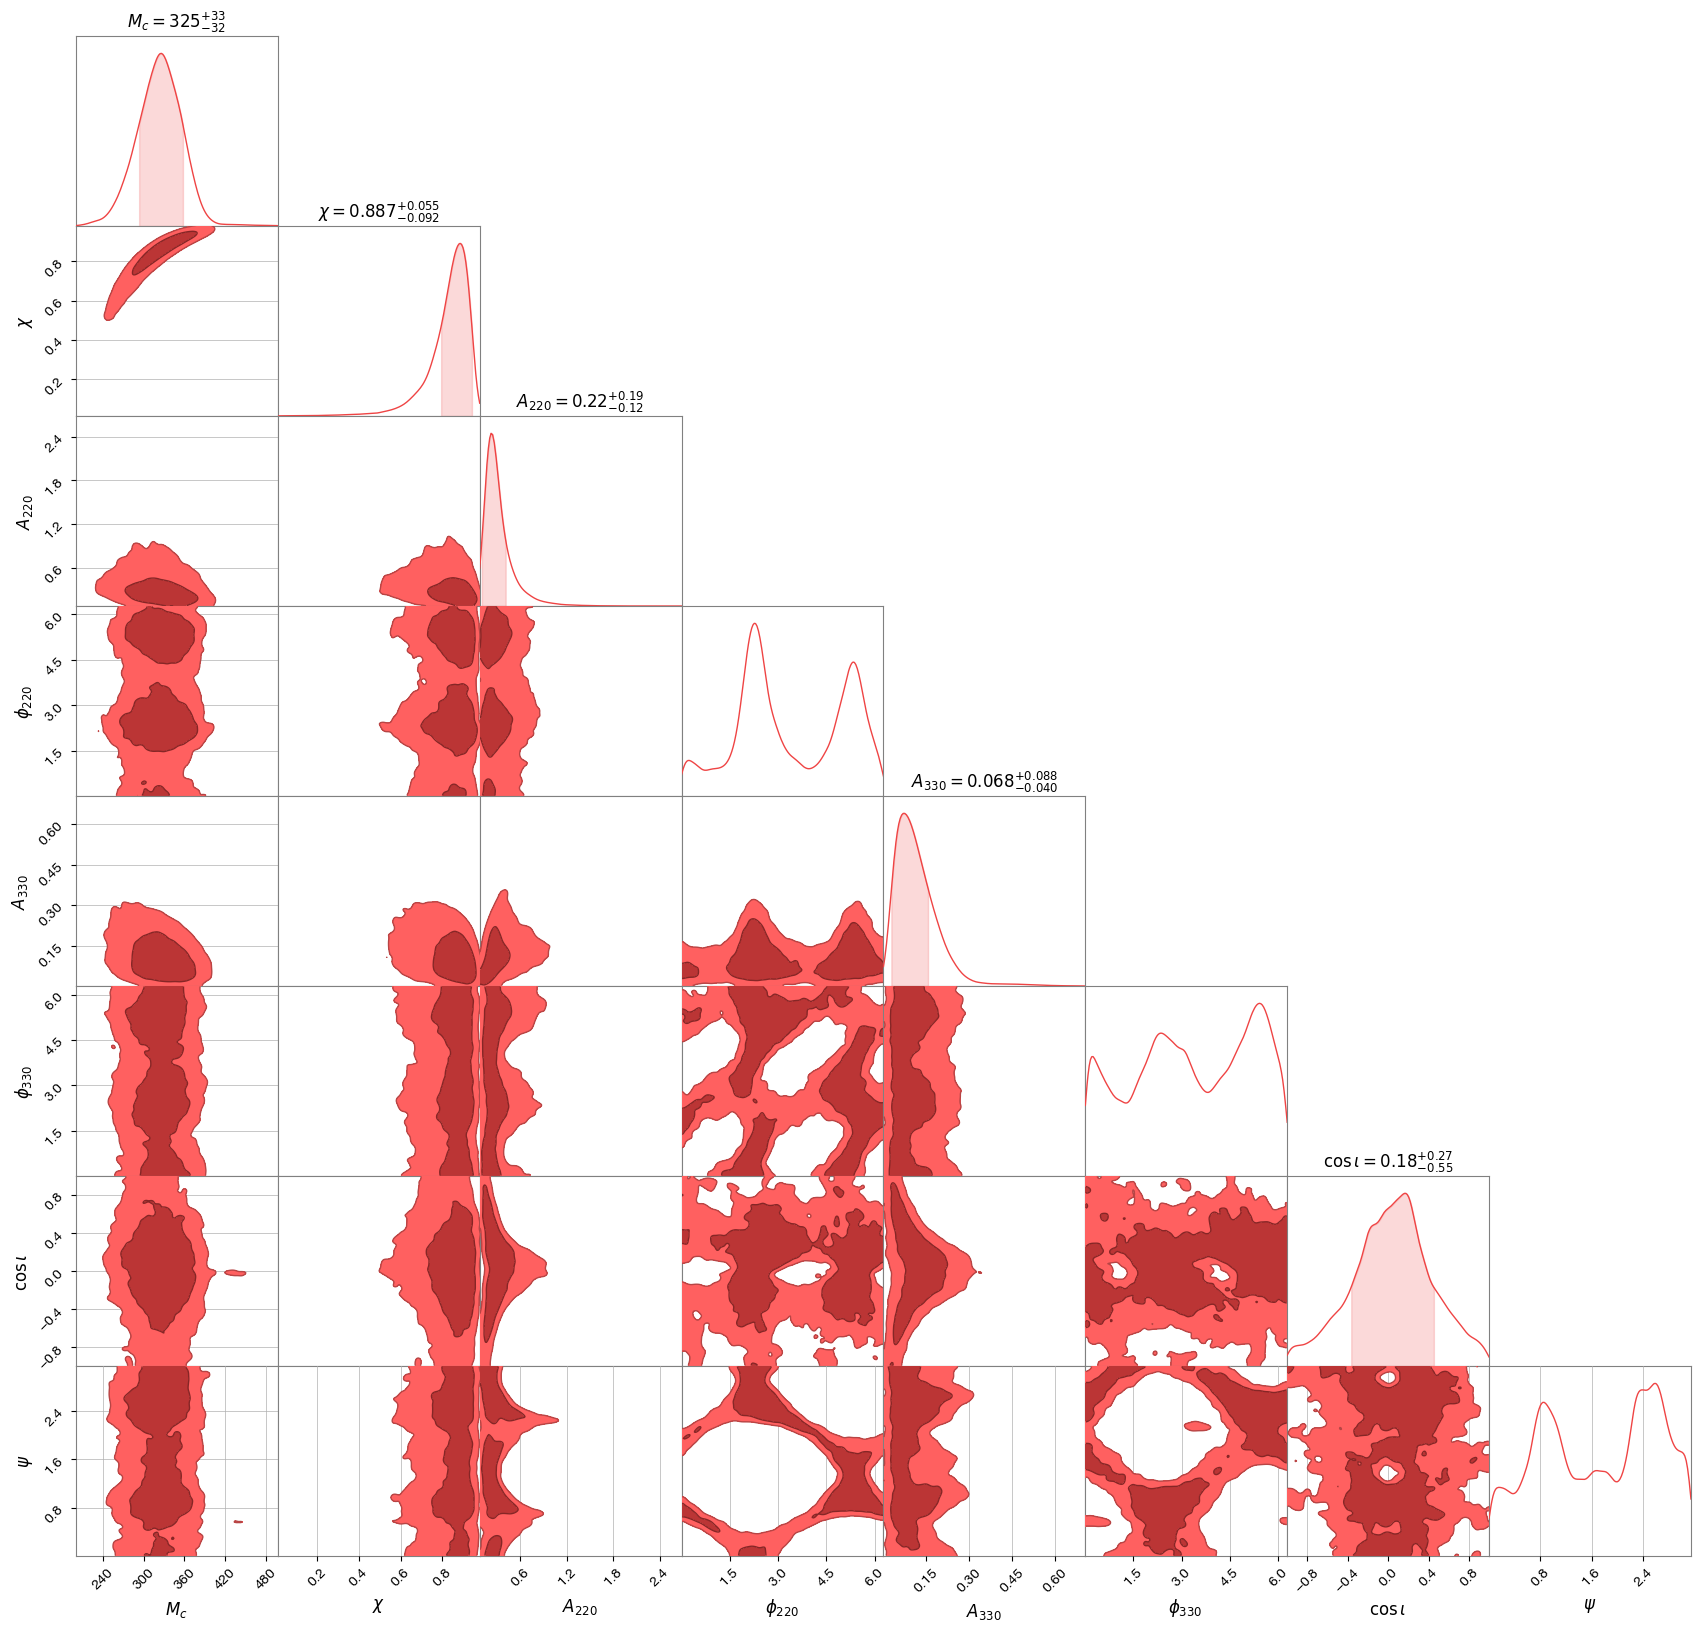

In [11]:
ns_fixed_tail_parameters = [r'$M_c$', r'$\chi$', r'$A_{220}$', r'$\phi_{220}$', r'$A_{330}$', r'$\phi_{330}$', r'$\cos\iota$', r'$\psi$']


df_ns_fixed_ext = pd.DataFrame(posterior_fixed_sky['theta'], columns=ns_fixed_tail_parameters)
c = ChainConsumer()
c.add_chain(Chain(samples=df_ns_fixed_ext, color='r', name="Fixed sky"))
c.set_override(ChainConfig(sigmas=[0, 1, 2]))
c.set_plot_config(
    PlotConfig(
        # flip=True,
        # labels=ns_parameters,
        contour_label_font_size=24,
        legend_kwargs={'fontsize': 30}
    )
)
fig = c.plotter.plot()
# plt.savefig(corner_path, dpi=300, bbox_inches='tight')
plt.show()

In [12]:
onp.save('posterior.' + event_id + '.fixed-sky.npy', onp.asarray(posterior_fixed_sky['theta']))

In [13]:
ns_fixed_sky._results.log_Z_mean

Array(-821.81065942, dtype=float64)

In [13]:
posterior_dir = '../posterior_files/fixed-sky/'
onp.save(posterior_dir + 'posterior.' + event_id + '.fixed-sky.npy', onp.asarray(posterior_fixed_sky['theta']))

In [14]:
print('logZ (330+220) : ', ns_fixed_sky._results.log_Z_mean)

logZ (330+220) :  -821.810659646811


Now set overtone amplitude to 0 to invoke 220 only model and calculate $\ln\mathcal{B}^{221+220}_{220}$

In [15]:
limits = [
    [150.0, 500.0],
    [0., 0.99],
    [0., 4.0],
    [0., 6.283185307179586],
    [-1., 1.],
    [0., 3.141592653589793]]

low  = onp.asarray([pair[0] for pair in limits], dtype=onp.float64)
high = onp.asarray([pair[1] for pair in limits], dtype=onp.float64)

Set up the numpyro sampler for 220 only model

In [16]:
low  = jnp.asarray(low,  dtype=jnp.float64)  
high = jnp.asarray(high, dtype=jnp.float64)  

theta_fixed_sky = jnp.array([ra, dec]) 


def make_loglik_fn(dataH, dataL, gmst, L_H, L_L,
                omega_22_r, omega_22_i, omega_33_r, omega_33_i,
                T, srate, t0):
    def _loglik(theta):
        return ln_likelihood_full_jit(
            dataH=dataH, dataL=dataL, params=theta,
            gmst=gmst, L_H=L_H, L_L=L_L,
            omega_22_r=omega_22_r, omega_22_i=omega_22_i,
            omega_33_r=omega_33_r, omega_33_i=omega_33_i,
            T=T, srate=srate, t0=t0
        )
    return _loglik

loglik_fn = make_loglik_fn(
    dataH=h_H_t, dataL=h_L_t,
    gmst=gmst, L_H=L_H, L_L=L_L,
    omega_22_r=omega_22_r, omega_22_i=omega_22_i,
    omega_33_r=omega_33_r, omega_33_i=omega_33_i,
    T=T, srate=srate, t0=t0
)

def model_fixed_sky_220():
    theta_free = numpyro.sample("theta", dist.Uniform(low, high))
    amp_phase_330 = jnp.array([0., 0.])
    theta = jnp.concatenate([theta_free[:4], amp_phase_330, theta_free[4:5], theta_fixed_sky, jnp.array([theta_free[-1]])], axis=0)
    numpyro.factor("loglike", loglik_fn(theta))

In [17]:
rng_key = jax.random.PRNGKey(int(seed) ^ 0xABCDEF)
rng_run, rng_post = jax.random.split(rng_key)
ns_fixed_sky_220 = NestedSampler(
    model_fixed_sky_220,
    constructor_kwargs=dict(
        num_live_points=10000,   
        max_samples=500_000,     
        verbose=False,
    ),
    termination_kwargs=dict(
        dlogZ=0.01,             
    ),
)
ns_fixed_sky_220.run(rng_run)
ns_fixed_sky_220.print_summary()
posterior_fixed_sky_220 = ns_fixed_sky_220.get_samples(rng_post, num_samples=100_000)

INFO:jaxns:Number of Markov-chains set to: 10000


Running over 12 devices.
--------
Termination Conditions:
Small remaining evidence
--------
likelihood evals: 18546160
samples: 160128
phantom samples: 0
likelihood evals / sample: 115.8
phantom fraction (%): 0.0%
--------
logZ=-822.336 +- 0.039
max(logL)=-808.896
H=-10.71
ESS=20872
--------
theta[#]: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
theta[0]: 349.0 +- 26.0 | 314.0 / 351.0 / 381.0 | 365.0 | 365.0
theta[1]: 0.904 +- 0.052 | 0.841 / 0.915 / 0.954 | 0.935 | 0.935
theta[2]: 0.2 +- 0.12 | 0.1 / 0.17 / 0.34 | 0.27 | 0.27
theta[3]: 3.4 +- 1.8 | 1.0 / 3.1 / 5.6 | 2.3 | 2.3
theta[4]: 0.07 +- 0.49 | -0.64 / 0.09 / 0.73 | 0.06 | 0.06
theta[5]: 1.61 +- 0.88 | 0.38 / 1.59 / 2.79 | 2.48 | 2.48
--------


In [18]:
print('logZ (220) : ', ns_fixed_sky_220._results.log_Z_mean)

logZ (220) :  -822.3364053418161


In [19]:
ns_fixed_sky._results.log_Z_mean - ns_fixed_sky_220._results.log_Z_mean

Array(0.5257457, dtype=float64)